In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Event_Revenue_Prediction\data\movies_data.csv', encoding='latin-1')
df.head()

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
0,13 Hours,Michael Bay,144,Toby Stephens,James Badge Dale,David Costabile,Action,50000000,69400000,50.00,69.23,19400000,0,0.0,2016,7.4
1,16 Blocks,Richard Donner,102,Bruce Willis,David Zayas,Sasha Roiz,Action,52000000,65000000,33.33,50.00,13000000,0,0.0,2006,6.6
2,17 Again,Burr Steers,102,Matthew Perry,Hunter Parrish,Thomas Lennon,Comedy,20000000,139000000,44.44,25.00,119000000,0,0.0,2009,6.4
3,1982,Tommy Oliver,90,Bokeem Woodbine,Ruby Dee,Quinton Aaron,Drama,1000000,2000000,50.00,100.00,1000000,0,0.0,2013,7.1
4,2 Fast 2 Furious,John Singleton,107,Paul Walker,Cole Hauser,Mo Gallini,Action,76000000,236000000,75.00,42.85,160000000,0,0.0,2003,5.9


In [3]:
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()

Movie                                  0
Director                               0
Running time                           0
Actor 1                                0
Actor 2                                0
Actor 3                                0
Genre                                  0
Budget                                 0
Box Office                             0
Actors Box Office %                    0
Director Box Office %                  0
Earnings                               0
Oscar and Golden Globes nominations    0
Oscar and Golden Globes awards         0
Release year                           0
IMDb score                             0
dtype: int64

In [4]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [5]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.lower()
df.columns

Index(['movie', 'director', 'running_time', 'actor_1', 'actor_2', 'actor_3',
       'genre', 'budget', 'box_office', 'actors_box_office_%',
       'director_box_office_%', 'earnings',
       'oscar_and_golden_globes_nominations', 'oscar_and_golden_globes_awards',
       'release_year', 'imdb_score'],
      dtype='object')

In [ ]:
df['roi'] = df['earnings'] / df['budget']
df['movie_age'] = 2026 - df['release_year']
df['total_awards'] = df['oscar_and_golden_globes_awards'] + df['oscar_and_golden_globes_nominations']
df['revenue_per_minute'] = df['box_office'] / df['running_time']
df['success'] = np.where(df['roi'] > 1, 1, 0)
df['genre_avg_box_office'] = df.groupby('genre')['box_office'].transform('mean')
df['director_avg_box_office'] = df.groupby('director')['box_office'].transform('mean')
df['actor_1_avg_box_office'] = df.groupby('actor_1')['box_office'].transform('mean')
df['actor_2_avg_box_office'] = df.groupby('actor_2')['box_office'].transform('mean')
df['actor_3_avg_box_office'] = df.groupby('actor_3')['box_office'].transform('mean')
df['cast_popularity'] = df['actor_1_avg_box_office'] + df['actor_2_avg_box_office'] + df['actor_3_avg_box_office']
df.head()

,movie,director,running_time,actor_1,actor_2,actor_3,genre,budget,box_office,actors_box_office_%,...,movie_age,total_awards,revenue_per_minute,success,director_avg_box_office,actor_1_avg_box_office,actor_2_avg_box_office,actor_3_avg_box_office,cast_popularity,genre_avg_box_office
0,13 Hours,Michael Bay,144,Toby Stephens,James Badge Dale,David Costabile,Action,50000000,69400000,50.00,...,10,0.0,4.819444e+05,0,4.674077e+08,2.507000e+08,6.940000e+07,6.570000e+07,3.858000e+08,1.799528e+08
1,16 Blocks,Richard Donner,102,Bruce Willis,David Zayas,Sasha Roiz,Action,52000000,65000000,33.33,...,20,0.0,6.372549e+05,0,1.462727e+08,1.661893e+08,6.500000e+07,6.500000e+07,2.961893e+08,1.799528e+08
2,17 Again,Burr Steers,102,Matthew Perry,Hunter Parrish,Thomas Lennon,Comedy,20000000,139000000,44.44,...,17,0.0,1.362745e+06,1,5.147500e+07,5.633333e+07,1.336667e+08,1.315333e+08,3.215333e+08,6.554156e+07
3,1982,Tommy Oliver,90,Bokeem Woodbine,Ruby Dee,Quinton Aaron,Drama,1000000,2000000,50.00,...,13,0.0,2.222222e+04,0,2.000000e+06,3.875000e+07,9.633333e+07,1.050000e+07,1.455833e+08,6.076428e+07
4,2 Fast 2 Furious,John Singleton,107,Paul Walker,Cole Hauser,Mo Gallini,Action,76000000,236000000,75.00,...,23,0.0,2.205607e+06,1,8.281429e+07,1.171706e+08,1.254200e+08,2.360000e+08,4.785906e+08,1.799528e+08


In [13]:
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    return f'${x*1e-6:,.0f}M'

def billions(x, pos):
    return f'${x*1e-9:,.1f}B'

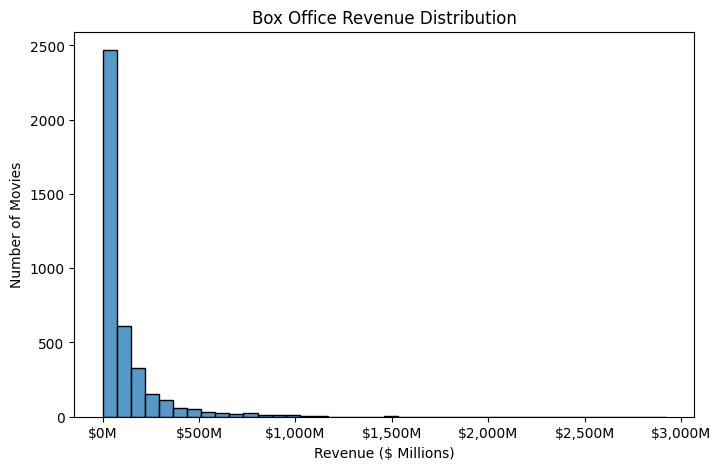

In [14]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(df["box_office"], bins=40, ax=ax)

ax.xaxis.set_major_formatter(FuncFormatter(millions))

ax.set_title("Box Office Revenue Distribution")
ax.set_xlabel("Revenue ($ Millions)")
ax.set_ylabel("Number of Movies")

plt.show()

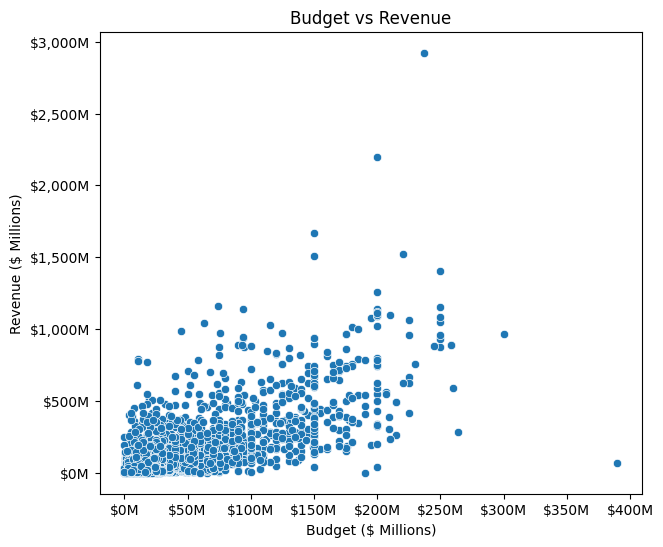

In [15]:
fig, ax = plt.subplots(figsize=(7,6))

sns.scatterplot(
    x=df["budget"],
    y=df["box_office"],
    ax=ax
)

ax.xaxis.set_major_formatter(FuncFormatter(millions))
ax.yaxis.set_major_formatter(FuncFormatter(millions))

ax.set_xlabel("Budget ($ Millions)")
ax.set_ylabel("Revenue ($ Millions)")
ax.set_title("Budget vs Revenue")

plt.show()

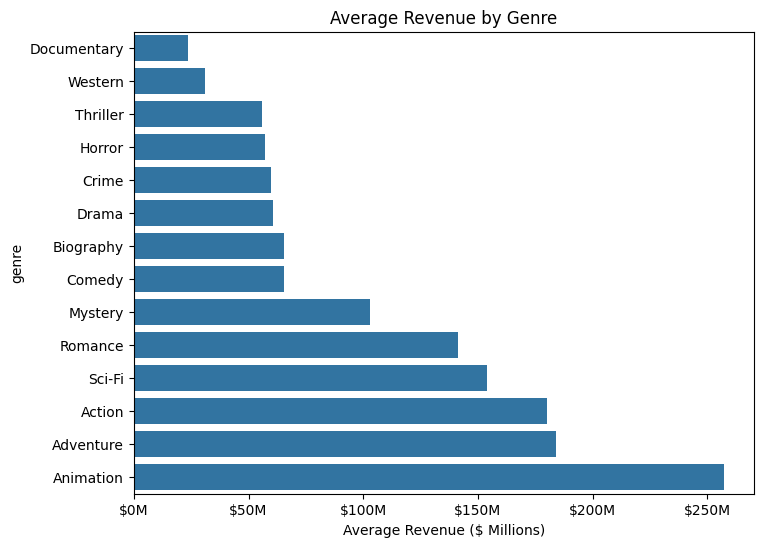

In [17]:
genre_avg = df.groupby("genre")["box_office"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(
    x=genre_avg.values,
    y=genre_avg.index,
    ax=ax
)

ax.xaxis.set_major_formatter(FuncFormatter(millions))

ax.set_xlabel("Average Revenue ($ Millions)")
ax.set_title("Average Revenue by Genre")

plt.show()

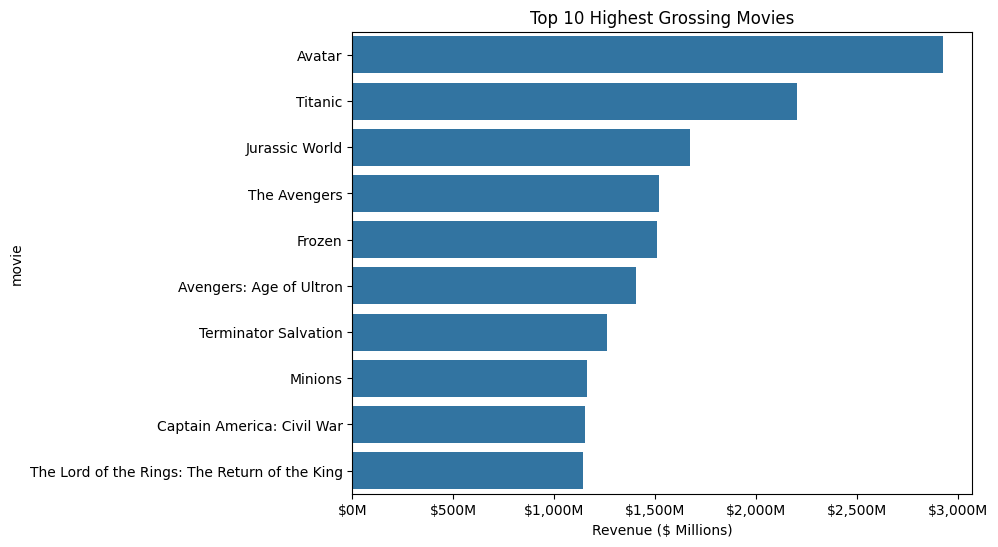

In [19]:
top_movies = df.sort_values("box_office", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(
    x=top_movies["box_office"],
    y=top_movies["movie"],
    ax=ax
)

ax.xaxis.set_major_formatter(FuncFormatter(millions))

ax.set_xlabel("Revenue ($ Millions)")
ax.set_title("Top 10 Highest Grossing Movies")

plt.show()

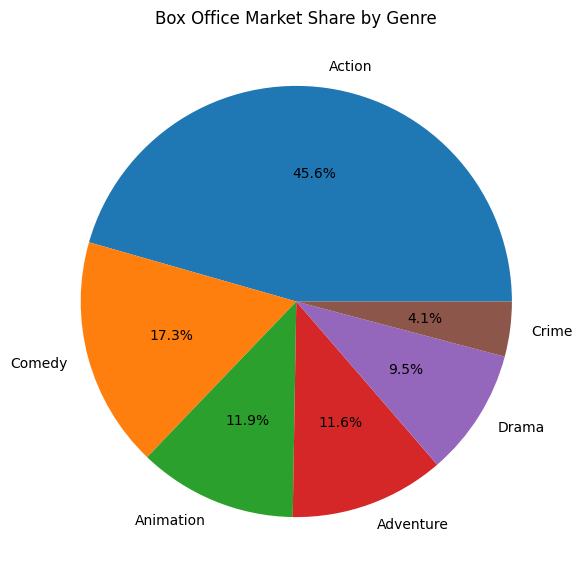

In [20]:
genre_revenue = df.groupby("genre")["box_office"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,7))

plt.pie(
    genre_revenue.head(6),
    labels=genre_revenue.head(6).index,
    autopct='%1.1f%%'
)

plt.title("Box Office Market Share by Genre")

plt.show()

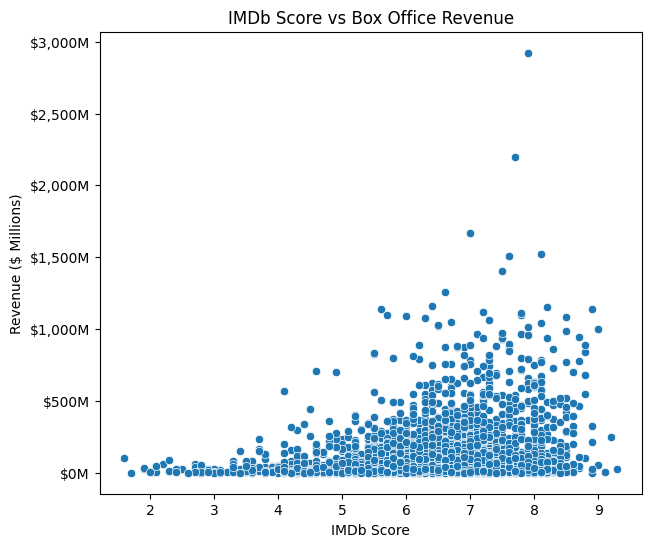

In [26]:
fig, ax = plt.subplots(figsize=(7,6))

sns.scatterplot(
    x=df["imdb_score"],
    y=df["box_office"],
    ax=ax
)

ax.yaxis.set_major_formatter(FuncFormatter(millions))

ax.set_xlabel("IMDb Score")
ax.set_ylabel("Revenue ($ Millions)")
ax.set_title("IMDb Score vs Box Office Revenue")

plt.show()

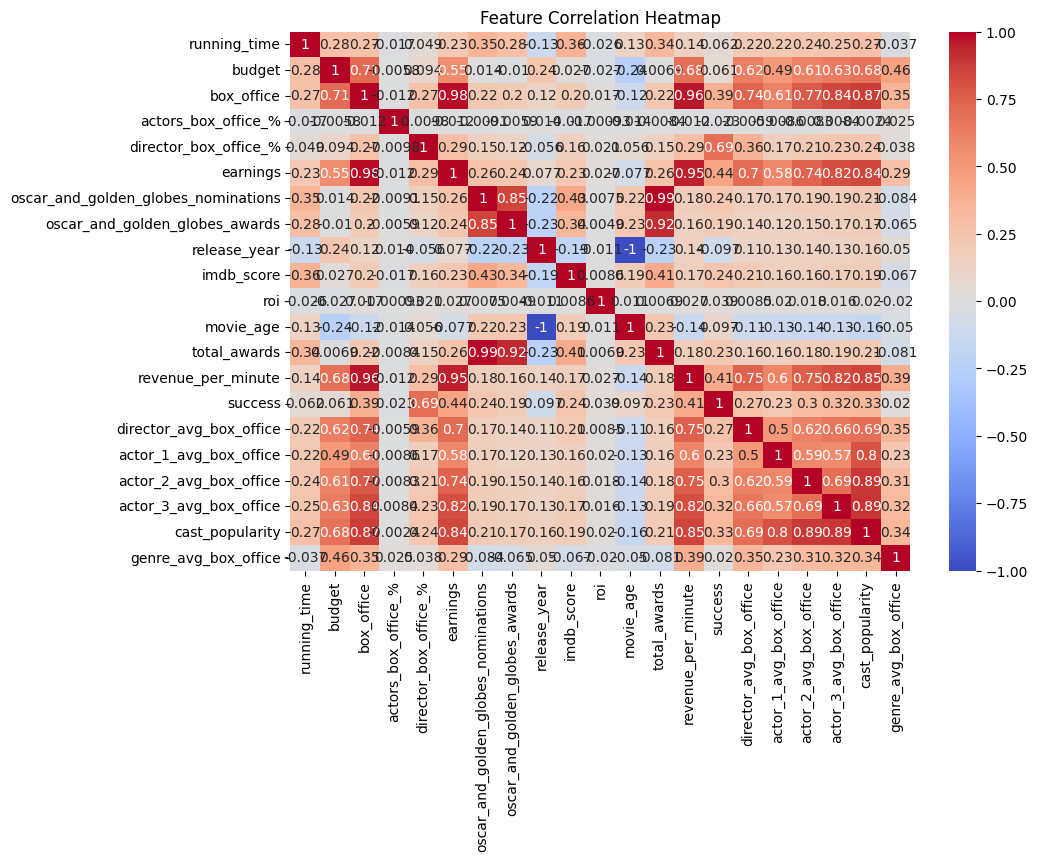

In [29]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()